#The Cybersecurity Autonomous System

## Introduction: Autonomous SOC & Operational Risk

Welcome to this interactive study on **Autonomous Security Operations Centers (SOC)**. In traditional cybersecurity education, we often focus on a binary question: *Is this activity malicious or benign?* If it is malicious, we block it; if it is benign, we allow it. However, real-world enterprise security is never that simple. This notebook is designed to shift your perspective from simple threat detection to **cybersecurity as a dynamic operational decision-making problem**.

### The Core Dilemma: Security vs. Continuity

Imagine you are the supervisor of a large bank's security systems. An alert flags suspicious activity on a server. Your automated tools suggest immediate isolation of the asset to prevent any potential spread of a cyber threat. But there is a catch: the flagged asset is the primary payments processing server.

If you isolate it immediately, you successfully contain any potential hazard. However, you also instantly halt millions of dollars in transactions, causing massive operational and reputational damage to the institution. If you wait for absolute certainty, the threat might spread and cause even greater systemic failure.

This is the core dilemma of a modern SOC: **both acting and waiting have real, quantifiable costs**.

### What Does This Notebook Cover?

To explore this trade-off, this notebook builds a fully self-contained, synthetic simulation of an enterprise network. Through it, we walk through the entire lifecycle of an autonomous decision-making system:

1. **Asset & Dependency Modeling:** We build a network of 120 assets (endpoints and servers). We assign each asset a 'criticality' score and map how they depend on one another. For example, a payment server is highly critical and has many dependent connections, whereas an individual employee workstation has low criticality.
2. **Telemetry & Perception:** We simulate background network traffic alongside specific suspicious events (scenarios). Our perception algorithms convert raw, noisy signals into structured 'evidence'.
3. **Threat Assessment:** We evaluate not just the isolated threat, but how likely it is to propagate to neighboring systems based on network dependencies.
4. **Judgment & Decision Making:** This is the heart of the system. Instead of simply reacting to threats, the system uses a balanced scoring framework. It prices in **evidence confidence, asset importance, operational impact, and action reversibility** before recommending a response.
5. **Governance & Authority:** We introduce a critical boundary. Even if a computer program determines that isolating a server is the best theoretical path, the system enforces a safety valve. Highly intrusive actions require human authorization ('Escalation'), while low-impact or highly reversible actions can be self-executed ('Auto-Approved').
6. **Feedback & Simulation:** We run multi-tick experiments, visualize how different defense policies affect overall business availability and system health, and build an interactive dashboard to test different risk thresholds.

By exploring this notebook, you will learn why true autonomous intelligence is not just about making predictions—it is about understanding operational limits, calculating collateral damage, and knowing when the machine must delegate authority back to a human.

## The problem

In [ ]:
# @title
# Cell 1 — purpose and architecture
from IPython.display import display, Markdown
display(Markdown(r"""
# Autonomous SOC: Judgment Under Operational Risk

## The problem
A Security Operations Center (SOC) does not merely ask *whether something looks suspicious*. It must decide what to do **while the institution is still operating**. A defensive action can reduce cyber risk and simultaneously damage the organization: isolating an identity server may stop propagation but also prevent thousands of legitimate users from authenticating; disabling a payment service may contain uncertainty but interrupt critical transactions.

This notebook therefore models cybersecurity as a **dynamic operations-and-judgment problem**, not as an offensive cyber exercise.

### Closed loop
**Telemetry → Perception → Threat assessment → Judgment → Governance gate → Defensive execution → Feedback → Reassessment**

The synthetic SOC balances six considerations:

1. estimated threat severity;
2. confidence in the evidence;
3. systemic importance of the affected asset;
4. likely propagation;
5. operational cost of intervention;
6. reversibility of the proposed action.

The central question is deliberately difficult:

> **When should the system intervene, and how aggressively, when both acting and waiting have costs?**

Everything here is synthetic. There are no real targets, credentials, exploits, payloads, malware instructions, or external scanning. The optional LLM is a bounded *supervisor*: it may comment on a small set of precomputed defensive choices, but deterministic code validates the final action.
"""))



# Autonomous SOC: Judgment Under Operational Risk

## The problem
A Security Operations Center (SOC) does not merely ask *whether something looks suspicious*. It must decide what to do **while the institution is still operating**. A defensive action can reduce cyber risk and simultaneously damage the organization: isolating an identity server may stop propagation but also prevent thousands of legitimate users from authenticating; disabling a payment service may contain uncertainty but interrupt critical transactions.

This notebook therefore models cybersecurity as a **dynamic operations-and-judgment problem**, not as an offensive cyber exercise.

### Closed loop
**Telemetry → Perception → Threat assessment → Judgment → Governance gate → Defensive execution → Feedback → Reassessment**

The synthetic SOC balances six considerations:

1. estimated threat severity;
2. confidence in the evidence;
3. systemic importance of the affected asset;
4. likely propagation;
5. operational cost of intervention;
6. reversibility of the proposed action.

The central question is deliberately difficult:

> **When should the system intervene, and how aggressively, when both acting and waiting have costs?**

Everything here is synthetic. There are no real targets, credentials, exploits, payloads, malware instructions, or external scanning. The optional LLM is a bounded *supervisor*: it may comment on a small set of precomputed defensive choices, but deterministic code validates the final action.


## Imports and Global Configuration



Cell 2 serves as the operational foundation for the entire simulation environment. It loads all necessary libraries, establishes mathematical and graphic frameworks, establishes system boundaries, and initializes global constants to ensure the simulation behaves predictably and realistically.

First, the cell imports standard python utilities like `os`, `json`, `math`, `random`, `statistics`, and `warnings`, along with specific typing and object-structuring mechanisms (`dataclasses`, `defaultdict`, `deque`, `typing`). It then imports scientific modules: `numpy` for scientific calculations, `pandas` for data structuring, `matplotlib.pyplot` for visual analysis, and `networkx` to build and analyze complex asset relationship graphs.

Second, to guarantee reproducibility, the global seed is configured to `SEED = 766`. Setting seeds for Python's native `random` and NumPy's `np.random` ensures that every user running this notebook will generate the exact same structure, background noise, and scenarios, creating a reliable baseline for auditing decisions.

Third, the cell defines critical system constraints:
* **`N_ENDPOINTS = 100`**: Simulates one hundred individual workstations.
* **`N_SERVERS = 20`**: Simulates twenty critical core services.
* **`MAX_TICKS = 120`**: Dictates the chronological length of our simulation run.

Finally, the cell sets up parameters for the optional bounded supervisory AI (`USE_LLM = False` by default). This design ensures that the entire code executes cleanly out-of-the-box without requiring API credentials, relying on a deterministic supervisor fallback instead. When executed, Cell 2 outputs a brief configuration summary to confirm that the environment is fully armed and prepared for active simulation.

In [ ]:
# Cell 2 — imports, reproducibility, and global configuration
import os, json, math, random, statistics, warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, Markdown

SEED = 766
random.seed(SEED)
np.random.seed(SEED)

N_ENDPOINTS = 100
N_SERVERS = 20
MAX_TICKS = 120

# Bounded supervisory AI is OFF by default so the notebook always runs.
USE_LLM = False
MODEL = os.getenv("SOC_SUPERVISOR_MODEL", "claude-haiku-4-5")
LLM_ENABLED = False
anthropic_client = None

print("Configuration loaded.")
print(f"Seed={SEED} | endpoints={N_ENDPOINTS} | servers={N_SERVERS} | ticks={MAX_TICKS}")


Configuration loaded.
Seed=766 | endpoints=100 | servers=20 | ticks=120


## Institution and Asset Model



Cell 3 establishes the structured digital inventory of our simulated enterprise, modeling the foundational components of the organization's network. It translates technical devices into distinct operational assets, assigning them attributes that define both their technical function and their business value.

First, the cell defines the structure of an **`Asset`** using Python's `@dataclass` decorator. Every asset contains key properties:
* **`asset_id`**: A unique identifier (e.g., "E001" for endpoints, "S001" for servers).
* **`kind`**: Classified as either an `endpoint` or a `server`.
* **`criticality`**: A scale from 0 to 1 representing the asset's importance to business survival.
* **`exposure`**: A metric reflecting how reachable or public-facing the asset is.
* **`health`**: A rating tracking the functional status of the asset (initialized to `1.0` or full health).
* **`isolated` / `monitoring`**: Boolean flags used to monitor whether the security system has taken containing or observing actions on the asset.
* **`service`**: The business department/function the asset belongs to.

Second, the cell declares eight enterprise business divisions (**`SERVICES`**), such as `identity`, `payments`, and `operations`.

Third, the **`build_assets()`** function generates a deterministic, randomized ecosystem of 120 assets (100 endpoints, 20 servers). Endpoints represent ordinary employee workstations and are assigned a lower, Gaussian-distributed criticality (averaging around `0.38`). Conversely, servers represent infrastructure backbones and are assigned specialized roles and a significantly higher criticality (averaging around `0.78`). Finally, the cell displays a structured `pandas.DataFrame` showing the first ten generated assets to verify their configuration.

By establishing these parameters, Cell 3 guarantees that any subsequent security actions can calculate potential collateral damage based on the specific criticality and service role of the affected asset.

In [ ]:
# Cell 3 — institution and asset model
@dataclass
class Asset:
    asset_id: str
    kind: str
    criticality: float
    exposure: float
    health: float = 1.0
    isolated: bool = False
    monitoring: bool = False
    service: str = "general"

SERVICES = [
    "identity", "payments", "customer_data", "communications",
    "analytics", "operations", "treasury", "general"
]

def build_assets(seed=SEED):
    rng = random.Random(seed)
    assets = {}
    for i in range(N_ENDPOINTS):
        service = rng.choice(SERVICES)
        crit = np.clip(rng.gauss(0.38, 0.16), 0.10, 0.80)
        assets[f"E{i:03d}"] = Asset(
            f"E{i:03d}", "endpoint", float(crit),
            float(np.clip(rng.gauss(0.45, 0.18), 0.05, 0.95)),
            service=service
        )
    server_services = (
        ["identity"]*3 + ["payments"]*3 + ["customer_data"]*3 +
        ["communications"]*2 + ["analytics"]*2 + ["operations"]*3 +
        ["treasury"]*2 + ["general"]*2
    )
    for i in range(N_SERVERS):
        service = server_services[i]
        crit = np.clip(rng.gauss(0.78, 0.12), 0.45, 1.00)
        assets[f"S{i:03d}"] = Asset(
            f"S{i:03d}", "server", float(crit),
            float(np.clip(rng.gauss(0.55, 0.15), 0.10, 0.95)),
            service=service
        )
    return assets

assets = build_assets()
display(pd.DataFrame([asdict(a) for a in list(assets.values())[:10]]))


,asset_id,kind,criticality,exposure,health,isolated,monitoring,service
0,E000,endpoint,0.432267,0.336466,1.0,False,False,analytics
1,E001,endpoint,0.255411,0.694543,1.0,False,False,analytics
2,E002,endpoint,0.197002,0.383506,1.0,False,False,analytics
3,E003,endpoint,0.228143,0.709551,1.0,False,False,payments
4,E004,endpoint,0.279875,0.354362,1.0,False,False,general
5,E005,endpoint,0.396539,0.512960,1.0,False,False,identity
6,E006,endpoint,0.659794,0.522140,1.0,False,False,treasury
7,E007,endpoint,0.325561,0.580224,1.0,False,False,payments
8,E008,endpoint,0.618255,0.552946,1.0,False,False,general
9,E009,endpoint,0.371858,0.234516,1.0,False,False,treasury


## The Synthetic Dependency Network

Cell 4 adds a layer of structural complexity to our asset model by defining how the simulated entities relate to and rely on one another. Real networks are not simple, isolated lists of devices; instead, they are rich, interconnected webs where an issue in one node can spread to another based on established network dependencies.

First, the cell introduces the **`build_network()`** function, which uses the **NetworkX** library to construct a mathematical, non-directed graph (`nx.Graph()`). Nodes are created for each of the 120 assets defined in the previous step, embedding their key attributes (such as whether they are an endpoint or a server, their business service department, and their overall criticality) directly into the graph nodes.

Second, the function creates logical dependencies (edges) representing data pathways between assets:
* **Endpoint-to-Server Dependencies**: Each workstation endpoint is mapped to between two and four random servers. This reflects how normal employees rely on core business utilities (like email, databases, or payment gateways). To ensure structural realism, the code prioritizes linking endpoints to servers within their own service department.
* **Server-to-Server Dependencies**: Servers also depend on other servers (for instance, a payment application server querying a backend database server). The code links each server to up to three other servers.

Third, each dependency edge is assigned a numerical **`dependency` weight** (ranging from `0.3` to `1.0`), which models the strength or importance of that connection. When run, Cell 4 prints a summary showing that it has successfully constructed a network of 120 nodes and 332 dependencies, establishing the critical mathematical pathways used to calculate propagation pressure in subsequent stages of the simulation.

In [ ]:
# Cell 4 — synthetic dependency network
def build_network(assets, seed=SEED):
    rng = random.Random(seed + 1)
    G = nx.Graph()
    for aid, a in assets.items():
        G.add_node(aid, kind=a.kind, service=a.service, criticality=a.criticality)

    endpoints = [k for k,a in assets.items() if a.kind == "endpoint"]
    servers = [k for k,a in assets.items() if a.kind == "server"]

    # Every endpoint depends on several services; servers also have bounded dependencies.
    for e in endpoints:
        candidates = sorted(
            servers,
            key=lambda s: (assets[s].service != assets[e].service, rng.random())
        )
        for s in candidates[:rng.randint(2, 4)]:
            G.add_edge(e, s, dependency=rng.uniform(0.3, 1.0))

    for i, s in enumerate(servers):
        others = [x for x in servers if x != s]
        for t in rng.sample(others, k=min(rng.randint(1, 3), len(others))):
            G.add_edge(s, t, dependency=rng.uniform(0.4, 1.0))
    return G

G = build_network(assets)
print(f"Synthetic institution: {G.number_of_nodes()} assets, {G.number_of_edges()} dependencies.")
print("No external network discovery is performed.")


Synthetic institution: 120 assets, 332 dependencies.
No external network discovery is performed.


##Telemetry Schema and Incident State

Cell 5 defines the structured data representations and persistent state tracking mechanisms that allow our simulated Security Operations Center (SOC) to perceive raw network events and organize them into continuous investigations.

First, the cell introduces the **`Signal`** structure using a Python `@dataclass`. Signals act as the raw, unrefined telemetry data generated by our systems at any given moment. Each `Signal` contains:
* **`tick`**: The specific time unit in the simulation when the telemetry was captured.
* **`asset_id`**: The target device being measured.
* **`category`**: The type of signal (e.g., baseline background traffic or a specific anomaly).
* **`anomaly`**: A value between 0.0 and 1.0 indicating how unusual the recorded activity is.
* **`confidence`**: A value between 0.0 and 1.0 representing the system's trust in the sensor's accuracy.
* **`note`**: A descriptive log string explaining the context of the data.

Second, the cell establishes the **`Incident`** structure. While a `Signal` represents an instantaneous, single-point observation, an `Incident` represents an ongoing, coordinated threat. It tracks the security issue's unique ID, point of origin, basic severity, its stealth rating (how hard it is to detect), how likely it is to propagate to adjacent nodes, and a tuple of all assets currently affected.

Third, the cell initializes global state variables including `history` (to log cumulative performance statistics), `audit_log` (to record automated or escalated defense choices), `signals` (the complete registry of raw events), and `incidents` (the dict tracking active threats).

Finally, the **`synthetic_signal()`** helper function ensures that any newly created signal contains normalized numerical attributes, clipping anomaly and confidence metrics to strict mathematical boundaries [0, 1] to prevent computational errors in downstream calculations.

In [ ]:
# Cell 5 — telemetry and incident state
@dataclass
class Signal:
    tick: int
    asset_id: str
    category: str
    anomaly: float
    confidence: float
    note: str

@dataclass
class Incident:
    incident_id: str
    origin: str
    severity: float
    stealth: float
    propagation: float
    active: bool = True
    affected: Tuple[str, ...] = ()

history = []
audit_log = []
signals: List[Signal] = []
incidents: Dict[str, Incident] = {}

def synthetic_signal(tick, asset_id, category, anomaly, confidence, note):
    return Signal(
        tick, asset_id, category,
        float(np.clip(anomaly, 0, 1)),
        float(np.clip(confidence, 0, 1)),
        note
    )

print("Telemetry schema and incident state defined.")


Telemetry schema and incident state defined.


##  Defensive Action Vocabulary and Authorization Boundaries

Cell 6 establishes the standard playbook of defensive actions that our simulated Security Operations Center (SOC) can execute. Instead of relying on unconstrained, arbitrary commands, the simulation limits itself to a realistic vocabulary of security operations, setting clear structural boundaries on how intrusive and reversible each action is, as well as who has the authority to approve them.

First, the cell defines the **`ACTIONS`** dictionary, mapping six defensive moves to their technical and operational profiles:
* **`observe` & `increase_monitoring`**: Highly passive, completely reversible (`reversibility = 1.00`), and low-to-no impact on operations. They are fully automated and require no human intervention.
* **`rate_limit` & `isolate_endpoint`**: Semi-intrusive operations. Isolating a workstation prevents the spread of lateral movement with high effectiveness, while maintaining a high chance of undoing the action if it is a false alarm.
* **`isolate_server` & `suspend_service`**: Extreme responses with major collateral impacts. Disrupting core database, payment, or authentication servers carries severe operational costs and is less easily reversed. Therefore, these actions require human authorization.

Second, the cell introduces the **`allowed_actions()`** helper function. This enforces strict logical partitioning between endpoints and servers. For example, a workstation cannot undergo server isolation, and a critical server cannot undergo endpoint-specific containment.

Finally, the cell outputs this configuration as a structured `pandas.DataFrame`. This acts as a clear reference matrix, demonstrating how the SOC codifies its policy limits before a live simulation begins. This grid ensures that the model can weigh threat mitigation against operational survival, preventing automated routines from taking unauthorized, highly disruptive actions.

In [ ]:
# Cell 6 — defensive action vocabulary and authorization boundaries
ACTIONS = {
    "observe": {
        "intrusiveness": 0.00, "reversibility": 1.00, "authority": "automatic"
    },
    "increase_monitoring": {
        "intrusiveness": 0.08, "reversibility": 1.00, "authority": "automatic"
    },
    "rate_limit": {
        "intrusiveness": 0.25, "reversibility": 0.95, "authority": "automatic"
    },
    "isolate_endpoint": {
        "intrusiveness": 0.55, "reversibility": 0.90, "authority": "automatic"
    },
    "isolate_server": {
        "intrusiveness": 0.85, "reversibility": 0.75, "authority": "human"
    },
    "suspend_service": {
        "intrusiveness": 1.00, "reversibility": 0.60, "authority": "human"
    }
}

def allowed_actions(asset: Asset):
    base = ["observe", "increase_monitoring", "rate_limit"]
    if asset.kind == "endpoint":
        base.append("isolate_endpoint")
    else:
        base += ["isolate_server", "suspend_service"]
    return base

display(pd.DataFrame(ACTIONS).T)


,intrusiveness,reversibility,authority
observe,0.0,1.0,automatic
increase_monitoring,0.08,1.0,automatic
rate_limit,0.25,0.95,automatic
isolate_endpoint,0.55,0.9,automatic
isolate_server,0.85,0.75,human
suspend_service,1.0,0.6,human


## The Synthetic Scenario Generator

Cell 7 introduces the structured timeline of challenges, anomalies, and active security incidents that our simulated organization will face during the simulation. Instead of simulating real technical exploits, this cell models specific events at a higher, strategic level, detailing each event's impact, propagation probability, and stealth metrics.

First, the cell defines the **`create_scenario()`** function, which establishes a deterministic set of four pre-scheduled events triggered at specific chronological ticks using a localized random number generator (`SEED + 7`):
1. **Tick 15 (`benign_spike`)**: A low-severity, localized spike originating from a random endpoint. This mimics common, harmless anomalous events (such as an employee downloading a massive file) that often trigger false-positive security warnings.
2. **Tick 35 (`credential_anomaly`)**: A moderate-severity incident on a workstation endpoint. This event has a moderate stealth level (`0.55`) and a low probability (`0.18`) of propagating to neighboring systems.
3. **Tick 62 (`coordinated_incident`)**: A highly severe, stealthy incident originating from a critical backend server. Because it has a high propagation rate (`0.42`), this incident represents a major coordinated threat designed to spread laterally to neighboring assets.
4. **Tick 88 (`critical_service_anomaly`)**: A severe incident targetting the highly sensitive payments service. It represents a direct risk to core transactions.

Second, each incident is defined as a simple dictionary detailing its chronological start, origin asset, initial severity, stealth rating (how hard it is to detect), and propagation speed.

Finally, when executed, Cell 7 displays this schedule as a structured `pandas.DataFrame`. This acts as the pre-configured script for our environment, allowing us to evaluate exactly how the SOC responds to different risk levels and threat types.

In [ ]:
# Cell 7 — scenario generator
def create_scenario(assets, seed=SEED):
    rng = random.Random(seed + 7)
    endpoints = [k for k,a in assets.items() if a.kind == "endpoint"]
    servers = [k for k,a in assets.items() if a.kind == "server"]

    # Synthetic defensive scenarios: labels describe effects, not attack procedures.
    return [
        {
            "tick": 15, "kind": "benign_spike",
            "origin": rng.choice(endpoints),
            "severity": 0.30, "stealth": 0.20, "propagation": 0.00
        },
        {
            "tick": 35, "kind": "credential_anomaly",
            "origin": rng.choice(endpoints),
            "severity": 0.58, "stealth": 0.55, "propagation": 0.18
        },
        {
            "tick": 62, "kind": "coordinated_incident",
            "origin": rng.choice(servers),
            "severity": 0.82, "stealth": 0.62, "propagation": 0.42
        },
        {
            "tick": 88, "kind": "critical_service_anomaly",
            "origin": next(s for s in servers if assets[s].service == "payments"),
            "severity": 0.76, "stealth": 0.45, "propagation": 0.25
        },
    ]

scenario = create_scenario(assets)
display(pd.DataFrame(scenario))


,tick,kind,origin,severity,stealth,propagation
0,15,benign_spike,E022,0.30,0.20,0.00
1,35,credential_anomaly,E063,0.58,0.55,0.18
2,62,coordinated_incident,S011,0.82,0.62,0.42
3,88,critical_service_anomaly,S003,0.76,0.45,0.25


## The Synthetic Telemetry Engine

Cell 8 introduces the core engine responsible for generating all security signals within our simulated environment. In any live Enterprise Security Operations Center (SOC), security analysts do not deal with raw, structural configuration matrices directly; instead, they observe a constant stream of telemetry, logs, and alerts. This cell models that data stream by splitting telemetry generation into two distinct, deterministic subprocesses: background noise and targeted scenario event injection.

First, the **`emit_background_telemetry()`** function models the mundane, day-to-day noise of a healthy corporate network. In each tick, the function randomly samples twelve enterprise assets. For each sampled asset, it calculates a baseline noise metric using a Gaussian distribution, slightly elevated by that asset's external exposure parameter. This ensures that internet-facing devices naturally display higher baseline levels of unusual activity without representing active security threats. This baseline is then packed into a standardized telemetry `Signal` with low confidence metrics and labeled as routine synthetic telemetry.

Second, the **`inject_scenario_event()`** function simulates active security incidents. When a scheduled event from our scenario script triggers, this engine determines if and how the threat propagates. Using the NetworkX dependency graph (`G`), the system evaluates neighboring assets; if a randomized check beats the event's propagation threshold, the anomaly spreads laterally to adjacent systems. The engine then generates customized, high-severity telemetry signals for all affected systems, scaling the signal's confidence based on the event's stealth level.

Combined, these functions create a realistic telemetry environment where critical threat signals are masked by a persistent background noise, challenging the SOC's perception algorithms to accurately identify real exploits.

In [ ]:
# Cell 8 — synthetic telemetry engine
def emit_background_telemetry(tick, assets, rng):
    batch = []
    sampled = rng.sample(list(assets), k=12)
    for aid in sampled:
        a = assets[aid]
        baseline = np.clip(rng.gauss(0.10 + 0.08*a.exposure, 0.06), 0, 0.45)
        batch.append(synthetic_signal(
            tick, aid, "baseline", baseline,
            np.clip(0.45 + baseline, 0, 0.85),
            "Routine synthetic telemetry."
        ))
    return batch

def inject_scenario_event(tick, event, assets, G, rng):
    origin = event["origin"]
    affected = {origin}
    if event["propagation"] > 0:
        for n in G.neighbors(origin):
            if rng.random() < event["propagation"]:
                affected.add(n)

    out = []
    for aid in affected:
        severity = event["severity"] * rng.uniform(0.78, 1.05)
        confidence = np.clip(0.55 + severity*(1-event["stealth"]), 0.35, 0.98)
        out.append(synthetic_signal(
            tick, aid, event["kind"],
            np.clip(severity, 0, 1), confidence,
            "Synthetic scenario signal; defensive simulation only."
        ))
    return out, affected

print("Synthetic telemetry engine ready.")


Synthetic telemetry engine ready.


## The Perception Layer: Converting Raw Telemetry into Structured Evidence

Cell 9 defines the **`perceive()`** function, which acts as the "eyes" of our Security Operations Center. In a live enterprise network, raw log entries and telemetry signals are highly noisy and context-poor. The perception layer's job is to aggregate these disparate, fragmented, and sometimes contradictory signals over a given period, synthesizing them into a structured, actionable intelligence record for each unique asset.

To achieve this, the function first clusters incoming signals by their target asset identifier using a python `defaultdict`. It then calculates three essential, distinct metrics to evaluate the potential threat:
1. **Maximum Anomaly**: It identifies the single highest anomaly value reported among all signals for that asset, ensuring that a single critical warning is not diluted or averaged out by minor, routine alerts.
2. **Cumulative Confidence**: Using a multiplicative probability model (`1 - np.prod(...)`), the system simulates the compounding weight of multiple alerts. Instead of summing confidence, it measures the likelihood that at least one of the alerts is correct, capped at a maximum of `0.95` per alert. This reflects how security teams gain certainty as additional telemetry lines confirm an event.
3. **Alert Diversity**: It calculates how many unique log categories have triggered on that asset. Diverse alerts (such as a database query anomaly occurring alongside a port scan) indicate a higher likelihood of a real multi-stage attack.

Finally, the function computes a single weighted **Evidence Score** (`0.58*anomaly + 0.30*confidence + 0.12*diversity`), prioritizing the severity of anomalies while heavily factoring in our logical certainty. This score is packed into a structured `pandas.DataFrame`, sorted in descending order so that security teams can instantly identify which corporate systems require immediate, prioritized attention.

In [ ]:
# Cell 9 — perception: convert telemetry into evidence
def perceive(recent_signals: List[Signal], assets: Dict[str, Asset]):
    rows = []
    grouped = defaultdict(list)
    for s in recent_signals:
        grouped[s.asset_id].append(s)

    for aid, ss in grouped.items():
        anomaly = max(s.anomaly for s in ss)
        confidence = 1 - np.prod([1 - min(0.95, s.confidence*0.55) for s in ss])
        diversity = len(set(s.category for s in ss))
        evidence = np.clip(
            0.58*anomaly + 0.30*confidence + 0.12*min(1, diversity/3), 0, 1
        )
        rows.append({
            "asset_id": aid,
            "evidence": float(evidence),
            "anomaly": float(anomaly),
            "confidence": float(confidence),
            "criticality": assets[aid].criticality,
            "service": assets[aid].service,
            "kind": assets[aid].kind
        })
    return pd.DataFrame(rows).sort_values("evidence", ascending=False) if rows else pd.DataFrame()

print("Perception layer defined.")


Perception layer defined.


## Threat Assessment and Propagation Context

Cell 10 introduces the threat assessment layer, which elevates basic security signals into contextual enterprise intelligence. While the perception layer in Cell 9 calculates isolated asset telemetry, Cell 10 evaluates threat levels through the lens of topological network relationships. In real-world enterprise environments, an isolated attack on an unimportant, non-connected test workstation is significantly less dangerous than an attack on a system positioned as a gateway to high-value servers. This cell resolves that dynamic by modeling "propagation pressure" across the enterprise dependency graph.

First, the **`local_propagation_pressure()`** function calculates how much risk is bleeding over from neighboring assets. Using the NetworkX dependency graph (`G`), the system retrieves all direct neighbors of a targeted asset. It then aggregates the current evidence scores of those neighbors, computing a combination of their mean evidence and a weighted factor (`0.25`) of the maximum neighbor threat. This means that if an asset is surrounded by highly compromised systems, its propagation pressure rises significantly, reflecting the imminent lateral threat it faces.

Second, the **`assess_threat()`** function synthesizes these parameters into a final **Threat Score**. It computes a weighted average of three distinct pillars: the asset's individual evidence score (`62%`), its topological propagation pressure (`23%`), and the raw, unmitigated anomaly value (`15%`).

By integrating the network's topology, this formula ensures that high-anomaly events occurring near critical infrastructure or highly connected nodes bubble up to the top of the queue. The resulting sorted dataframe gives the autonomous SOC a geographically and topologically contextualized prioritization queue, ensuring that response strategies target critical points of lateral movement rather than just isolated alerts.

In [ ]:
# Cell 10 — threat assessment and propagation context
def local_propagation_pressure(aid, evidence_map, G):
    neigh = list(G.neighbors(aid))
    if not neigh:
        return 0.0
    vals = [evidence_map.get(n, 0.0) for n in neigh]
    return float(np.clip(np.mean(vals) + 0.25*max(vals, default=0), 0, 1))

def assess_threat(perception_df, G):
    if perception_df.empty:
        return perception_df
    df = perception_df.copy()
    evidence_map = dict(zip(df.asset_id, df.evidence))
    df["propagation_pressure"] = [
        local_propagation_pressure(a, evidence_map, G) for a in df.asset_id
    ]
    df["threat"] = np.clip(
        0.62*df.evidence +
        0.23*df.propagation_pressure +
        0.15*df.anomaly,
        0, 1
    )
    return df.sort_values("threat", ascending=False)

print("Threat assessment layer defined.")


Threat assessment layer defined.


## The Operational Consequence Model

Cell 11 establishes the critical mathematical compromise at the heart of our autonomous SOC: the operational consequence model. In any live enterprise security framework, defensive containment actions do not occur in a vacuum. Disconnecting a machine, blocking network access, or shutting down a database can cripple vital business operations. Therefore, this cell programmatically evaluates both the **Operational Cost** of a security intervention and its anticipated **Security Benefit**.

First, the **`operational_cost()`** function models the real-world impact of a security action on business continuity. It assesses the asset's system criticality, its connectivity load (utilizing the NetworkX graph's node degree normalized against the maximum degree in the network), and whether it hosts high-priority services such as payments or identity services. High-impact services scale the operational cost multiplier, while the intrinsic 'intrusiveness' rating of the proposed defensive action (derived from our global `ACTIONS` configuration in Cell 6) dictates the base cost. Consequently, isolating a highly connected payment hub is mathematically modeled as an exceptionally expensive action, while merely observing an isolated client endpoint incurs zero operational cost.

Second, the **`security_benefit()`** function computes the potential mitigation value of a candidate action. This is a function of the action's inherent historical effectiveness paired with the urgency of the situation (a weighted combination of the asset's current threat score at `72%` and its topological propagation threat at `28%`).

By calculating these opposing metrics, the simulation moves beyond simplistic rule-based triggers. It builds a realistic model where the SOC must justify its defensive actions. The system is forced to balance risk reduction against business self-preservation, ensuring that the cure is never operationally worse than the disease.

In [ ]:
# Cell 11 — operational consequence model
def operational_cost(asset: Asset, action: str, G):
    meta = ACTIONS[action]
    dependency_load = G.degree(asset.asset_id) / max(1, max(dict(G.degree()).values()))
    service_multiplier = 1.20 if asset.service in {"identity", "payments", "treasury"} else 1.0
    return float(np.clip(
        meta["intrusiveness"] *
        (0.50*asset.criticality + 0.30*dependency_load + 0.20*service_multiplier),
        0, 1
    ))

def security_benefit(threat, propagation, action):
    effectiveness = {
        "observe": 0.02,
        "increase_monitoring": 0.15,
        "rate_limit": 0.35,
        "isolate_endpoint": 0.78,
        "isolate_server": 0.88,
        "suspend_service": 0.95
    }[action]
    return float(np.clip(effectiveness*(0.72*threat + 0.28*propagation), 0, 1))

print("Operational consequence model defined.")


Operational consequence model defined.


## The Judgment Layer: Ranking Defensible Actions

Cell 12 implements the multi-attribute utility theory model used by our autonomous agent to calculate the relative "goodness" of every allowed security posture change. When an enterprise system is identified as being under threat, simply picking the most aggressive mitigation strategy is rarely appropriate. Instead, the autonomous agent must evaluate each candidate defense systematically, balancing four competing, real-world operational and technical criteria: immediate utility, operational disruption, institutional stability, and uncertainty mitigation.

To accomplish this, the **`judge_actions()`** function iterates through all permitted actions for a targeted asset. For each option, it pulls the calculated security benefit and operational cost from Cell 11 and retrieves the action's inherent reversibility score. Critically, the formula introduces an **Uncertainty Penalty** (`(1 - confidence) * intrusiveness * 0.45`). This penalty models a core principle of defensive engineering: highly intrusive, disruptive actions (such as server isolation) should not be performed when threat signals are weak or unconfirmed. If the alert confidence is low, the uncertainty penalty increases, lowering the option's total utility rating.

All variables are synthesized into a single, multi-criteria decision score using highly parameterized weights:
$$\text{Score} = 0.48 \times \text{Benefit} - 0.30 \times \text{Operational Cost} + 0.14 \times \text{Reversibility} - 0.08 \times \text{Uncertainty Penalty}$$

This mathematical formulation structures the agent's behavior. The 48% weight on security benefits ensures that security remains a top priority, while the 30% penalty on operational cost stops the agent from unnecessarily disabling critical infrastructure. By accounting for reversibility and uncertainty, the engine acts as an mathematically sound decision framework, ranking all potential actions and delivering a clear recommendation list.

In [ ]:
# Cell 12 — judgment: rank defensible actions
def judge_actions(asset: Asset, threat: float, confidence: float,
                  propagation: float, G):
    candidates = []
    for action in allowed_actions(asset):
        benefit = security_benefit(threat, propagation, action)
        op_cost = operational_cost(asset, action, G)
        reversible = ACTIONS[action]["reversibility"]

        # Judgment is not "maximize threat reduction": it explicitly prices
        # uncertainty, institutional importance, collateral cost and reversibility.
        uncertainty_penalty = (1-confidence) * ACTIONS[action]["intrusiveness"] * 0.45
        score = (
            0.48*benefit
            - 0.30*op_cost
            + 0.14*reversible
            - 0.08*uncertainty_penalty
        )
        candidates.append({
            "action": action,
            "score": float(score),
            "security_benefit": benefit,
            "operational_cost": op_cost,
            "reversibility": reversible,
            "authority": ACTIONS[action]["authority"]
        })
    return pd.DataFrame(candidates).sort_values("score", ascending=False)

print("Judgment layer defined.")


Judgment layer defined.


## The Governance Gate: Establishing Guardrails for Autonomous Action

Cell 13 introduces the **`governance_gate()`** function, which represents a crucial architectural safeguard within our autonomous SOC. While prior cells leverage sophisticated utility scoring algorithms to rank optimal mitigations, this cell acts as a deterministic compliance check. In production enterprise networks, completely unchecked software automation is a severe liability. If an AI agent were to autonomously isolate a critical payment gateway based on a false positive alert, the resulting self-inflicted downtime could cause catastrophic financial and reputational damage. The governance gate serves as a critical circuit breaker that validates proposed interventions against legal, institutional, and compliance boundaries.

To achieve this, the governance gate acts on two distinct operational principles: explicit delegation of authority and confidence-based thresholds. First, the function checks the proposed action's predefined authority level. Highly intrusive actions—specifically `isolate_server` or `suspend_service`—are marked under our global configuration as requiring `human` authority. If the agent's utility-maximizing function suggests one of these actions, the gate blocks automatic execution and flags the state as `ESCALATE`. This ensures that severe business-disrupting decisions always require manual confirmation from a security analyst.

Second, the gate enforces safety boundaries for automatic containment actions (like `rate_limit` or `isolate_endpoint`). Even if these actions are theoretically auto-approved, the gate evaluates the security engine's confidence level. If the proposed action has an intrusiveness rating of `0.5` or higher, but our sensory evidence has a confidence score lower than `0.58`, the action is blocked and escalated. This prevents the system from taking radical containment measures based on weak, unconfirmed alerts. By structuring these deterministic safety gates, the enterprise maintains complete operational sovereignty over the autonomous agent.

In [ ]:
# Cell 13 — governance gate
def governance_gate(asset: Asset, proposal: dict, threat: float, confidence: float):
    action = proposal["action"]
    authority = ACTIONS[action]["authority"]

    # High-impact server/service actions never silently self-authorize.
    if authority == "human":
        return {
            "approved": False,
            "status": "ESCALATE",
            "reason": "High-impact action requires human authorization."
        }

    # Even an automatic action is bounded when confidence is weak.
    if ACTIONS[action]["intrusiveness"] >= 0.5 and confidence < 0.58:
        return {
            "approved": False,
            "status": "ESCALATE",
            "reason": "Evidence confidence is insufficient for automatic containment."
        }

    return {
        "approved": True,
        "status": "AUTO_APPROVED",
        "reason": "Action is inside the bounded defensive authority."
    }

print("Governance gate defined.")


Governance gate defined.


## The Bounded LLM Supervisory Gateway

Cell 14 introduces the **`setup_optional_llm()`** function, which establishes the infrastructure for our bounded LLM supervisory gateway. In modern security operations, large language models (LLMs) are increasingly integrated to offer high-level reasoning and cognitive oversight over complex events. However, introducing a generative model into a critical, closed-loop execution environment poses significant operational risks. If the LLM connection fails, latency spikes, or an API key expires, the entire security response pipeline could freeze. To prevent this, Cell 14 implements a resilient, fail-safe setup routine.

First, the function checks the global configuration flag `USE_LLM`. If the user has disabled the language model globally, the setup immediately exits and enforces a fully deterministic execution mode. If enabled, the function attempts to securely import the third-party Anthropic library and locate an API key. To respect secure development practices within Google Colab, the code attempts to retrieve the key from the environment variables first, falling back to Colab's encrypted `userdata` secrets manager if the system environment lacks the credential.

Second, the gateway is wrapped in a robust `try-except` block. If any error occurs—such as a missing library, an invalid API key, or a lack of internet connectivity—the exception is caught, logged, and silenced. Instead of crashing the notebook runtime, the system automatically falls back to a deterministic, rule-based controller. It disables the `LLM_ENABLED` global flag and prints a warning that the deterministic supervisor remains active. This design pattern teaches a vital cybersecurity engineering principle: advanced AI reasoning systems should always be designed as optional, plug-and-play enhancements running on top of a highly reliable, deterministic base layer.

In [ ]:
# Cell 14 — bounded LLM supervisory gateway
def setup_optional_llm():
    global LLM_ENABLED, anthropic_client
    if not USE_LLM:
        LLM_ENABLED = False
        return False
    try:
        from anthropic import Anthropic
        key = os.getenv("ANTHROPIC_API_KEY")
        if not key:
            try:
                from google.colab import userdata
                key = userdata.get("ANTHROPIC_API_KEY")
            except Exception:
                key = None
        if not key:
            print("No ANTHROPIC_API_KEY found; deterministic supervisor remains active.")
            LLM_ENABLED = False
            return False
        anthropic_client = Anthropic(api_key=key)
        LLM_ENABLED = True
        return True
    except Exception as e:
        print(f"Optional LLM unavailable ({type(e).__name__}); deterministic fallback remains active.")
        LLM_ENABLED = False
        return False

setup_optional_llm()
print(f"Optional LLM enabled: {LLM_ENABLED}")


Optional LLM enabled: False


## The Supervisor Layer: Policy Alignment and LLM Integration

Cell 15 introduces the supervising logic of our autonomous SOC, implementing two alternative pathways for action validation: the **`deterministic_supervisor()`** and the **`llm_supervisor()`**. In modern automated architectures, agents must not only evaluate raw mathematical utility functions but also align their proposed interventions with high-level operational policies. This cell showcases how cognitive tools, such as Large Language Models (LLMs), can safely provide semantic reasoning over security contexts without possessing unconstrained, dangerous write access to the underlying infrastructure.

First, the **`deterministic_supervisor()`** acts as our control baseline. It automatically validates the top-ranked recommendation from Cell 12, generating a structured, template-based explanation of the action's balance between security benefit, operational cost, and reversibility. This ensures that the system always has a fast, reliable decision mechanism if advanced cognitive resources are offline.

Second, the **`llm_supervisor()`** introduces an optional, highly advanced cognitive layer. If the gateway setup in Cell 14 is successful, this function compiles a compact, sanitized JSON context detailing the asset's function, threat level, propagation pressure, and list of permitted actions. It passes this state to an external Anthropic model with strict system prompting. The model is forbidden from proposing offensive maneuvers, unauthorized system commands, or unvetted actions. It is restricted to choosing exactly one valid action from the pre-approved list and outputting its reasoning in a clean JSON schema.

To ensure robustness, the returned action is cross-checked against the permitted actions. If the model hallucinations occur, or the API request fails, the pipeline silently triggers the deterministic fallback. This structure demonstrates a key security principle: LLMs should be employed as isolated, advisory processing nodes rather than direct execution engines.

In [ ]:
# Cell 15 — supervisor: explanation without unconstrained control
def deterministic_supervisor(context):
    p = context["proposal"]
    return {
        "recommended_action": p["action"],
        "rationale": (
            f"Prefer {p['action']} because its estimated defensive benefit "
            f"({p['security_benefit']:.2f}) is balanced against operational cost "
            f"({p['operational_cost']:.2f}) and reversibility "
            f"({p['reversibility']:.2f})."
        ),
        "source": "deterministic"
    }

def llm_supervisor(context):
    if not (USE_LLM and LLM_ENABLED):
        return deterministic_supervisor(context)

    allowed = context["allowed_actions"]
    compact = {
        "asset_kind": context["asset_kind"],
        "service": context["service"],
        "threat": round(context["threat"], 3),
        "confidence": round(context["confidence"], 3),
        "propagation": round(context["propagation"], 3),
        "allowed_actions": allowed,
        "deterministic_proposal": context["proposal"]["action"]
    }

    try:
        msg = anthropic_client.messages.create(
            model=MODEL,
            max_tokens=220,
            messages=[{
                "role": "user",
                "content": (
                    "You are a bounded defensive SOC supervisor in a synthetic simulation. "
                    "Choose exactly one action from allowed_actions. Do not propose offensive "
                    "actions, scanning, exploitation, persistence, credential access, or commands. "
                    "Return JSON with keys recommended_action and rationale.\n"
                    + json.dumps(compact)
                )
            }]
        )
        raw = msg.content[0].text.strip()
        data = json.loads(raw[raw.find("{"):raw.rfind("}")+1])
        action = data.get("recommended_action")
        if action not in allowed:
            return deterministic_supervisor(context)
        return {
            "recommended_action": action,
            "rationale": str(data.get("rationale", ""))[:500],
            "source": "bounded_llm"
        }
    except Exception:
        return deterministic_supervisor(context)

print("Supervisor defined with deterministic fallback and action validation.")


Supervisor defined with deterministic fallback and action validation.


## The Defensive Execution Engine

Cell 16 introduces the **`execute_defensive_action()`** function, which acts as the physical actuator layer of our autonomous SOC simulation. Once a defensive action has successfully passed through the multi-criteria utility ranking and the deterministic safety constraints of the governance gate, it is passed to this execution engine to be applied directly to the targeted asset. This cell demonstrates the critical state changes and operational side effects that occur when defensive interventions are executed.

First, the function records a snapshot of the asset's current state—specifically tracking its network isolation status (`isolated`), its deep monitoring level (`monitoring`), and its overall operational capacity (`health`). This backup state (`before`) is critical for auditing and allows the system to easily rollback containment actions when an incident is resolved.

Second, the execution engine maps the chosen action to specific property alterations on the target system:
* **`increase_monitoring`**: This action is low-impact and changes the asset's monitoring state to `True`. Because it is passive, it carries no operational penalty or performance degradation.
* **`rate_limit`**: This action restricts network bandwidth to mitigate attacks. It incurs a small operational performance penalty, reducing the asset's overall operational health by `5%` down to a minimum floor of `70%` capacity.
* **`isolate_endpoint`**: This action completely detaches user workstations (`endpoints`) from the corporate network, setting their `isolated` status to `True` and reducing their operational health by `10%` to reflect the massive disruption to local operations.

Third, the function contains an essential architectural boundary. Highly intrusive actions—specifically `isolate_server` and `suspend_service`—cannot be automatically executed by this code block. These actions immediately return a failure status (`False`), reflecting that high-impact corporate systems must never have their core infrastructure shut down without human-in-the-loop validation.

In [ ]:
# Cell 16 — defensive execution engine
def execute_defensive_action(asset: Asset, action: str):
    before = {"isolated": asset.isolated, "monitoring": asset.monitoring, "health": asset.health}

    if action == "increase_monitoring":
        asset.monitoring = True
    elif action == "rate_limit":
        asset.health = max(0.70, asset.health - 0.05)
    elif action == "isolate_endpoint" and asset.kind == "endpoint":
        asset.isolated = True
        asset.health = max(0.65, asset.health - 0.10)
    # Server isolation and service suspension require human approval and therefore
    # are not automatically executed by this notebook.
    elif action in {"isolate_server", "suspend_service"}:
        return False, before

    return True, before

print("Bounded defensive execution engine defined.")


Bounded defensive execution engine defined.


## Feedback Loops and Institutional Health Metrics

Cell 17 introduces the **`institutional_metrics()`** function, representing the telemetry loop that monitors overall enterprise health. In real-world Security Operations Centers, defense cannot be evaluated solely by the number of blocked attacks. A security team that stops 100% of threats by taking every single server and employee workstation offline has technically succeeded at defense, but has utterly failed the business. To capture this crucial tension, this cell calculates high-level operational performance and availability metrics after each simulation step.

First, the function computes overall **System Availability**. It filters the enterprise asset registry to find all systems where the `isolated` state is `False`. The ratio of these active machines to the total network size represents the basic operational status of the company. If the autonomous SOC becomes over-reactive and isolates too many systems, this availability metric drops, signaling an operational crisis.

Second, the function calculates **Critical Availability**. Some assets are more vital to business operations than others. By filtering for assets with a criticality rating of `0.70` or higher, the engine isolates core database clusters and payment gateways. Keeping these systems online is paramount; thus, the metric tracks the percentage of critical systems currently active, serving as a key performance indicator (KPI) for business continuity.

Finally, the function measures the **Mean Health** of the entire network. While availability is a binary measure of whether an asset is online, health represents performance degradation caused by passive containment actions like rate limiting. By averaging the health variables of all assets, the system tracks the cumulative friction caused by security interventions. Together, these metrics provide a quantitative, operational baseline that forces the autonomous SOC to justify its security choices against business performance.

In [ ]:

# Cell 17 — feedback and institutional health
def institutional_metrics(assets, G):
    available = [a for a in assets.values() if not a.isolated]
    availability = len(available) / len(assets)

    critical_assets = [a for a in assets.values() if a.criticality >= 0.70]
    critical_availability = (
        sum(not a.isolated for a in critical_assets) / max(1, len(critical_assets))
    )
    mean_health = float(np.mean([a.health for a in assets.values()]))

    return {
        "availability": float(availability),
        "critical_availability": float(critical_availability),
        "mean_health": mean_health
    }

print("Feedback metrics defined.")


Feedback metrics defined.


## The Autonomous SOC Decision Cycle

Cell 18 introduces the **`soc_decision_cycle()`** function, which serves as the central nervous system of our autonomous security architecture. In real-world environments, an automated security operations center (SOC) cannot act on unstructured raw data or implement actions in isolation. Instead, it must execute a highly coordinated, multi-step process that sequentially translates telemetry alerts into verified containment actions. This function brings together all the analytical modules developed in the previous cells to execute a single, unified round of security assessment and operational governance.

First, the decision cycle starts by querying the environment's telemetry stream through **`perceive()`** and translating these signals into asset-specific threat ratings via **`assess_threat()`**. To ensure that the system does not waste processing power or trigger disruptive containment protocols on insignificant issues, it filters out trivial alerts, only processing assets that exceed a calibrated threat threshold of `0.42`.

Second, for each qualifying high-threat asset, the pipeline initiates a deeper evaluation. It calls **`judge_actions()`** to construct and rank possible interventions based on their safety, cost, and utility. The top-ranked proposal, alongside the asset's complete contextual data, is then submitted to the **`llm_supervisor()`**. This supervisor acts as an intelligent, policy-checking gateway, returning its recommended action and written rationale.

Finally, the cycle enforces a critical layer of defense-in-depth. Rather than blindly executing the supervisor's recommendation, the system passes the proposed action to the **`governance_gate()`**. This gate checks the intervention against the target's criticality and risk tolerances to verify if autonomous containment is authorized. Only when this gate returns an approved status does the engine proceed to **`execute_defensive_action()`**, logging every step of the decision and action path inside an immutable audit log for human review.

In [ ]:
# Cell 18 — single SOC decision cycle
def soc_decision_cycle(tick, recent_signals, assets, G):
    perception = perceive(recent_signals, assets)
    assessed = assess_threat(perception, G)
    decisions = []

    if assessed.empty:
        return decisions

    for _, row in assessed.head(6).iterrows():
        # Avoid acting repeatedly on trivial background noise.
        if row.threat < 0.42:
            continue

        asset = assets[row.asset_id]
        ranked = judge_actions(
            asset, row.threat, row.confidence, row.propagation_pressure, G
        )
        proposal = ranked.iloc[0].to_dict()

        context = {
            "asset_kind": asset.kind,
            "service": asset.service,
            "threat": float(row.threat),
            "confidence": float(row.confidence),
            "propagation": float(row.propagation_pressure),
            "allowed_actions": allowed_actions(asset),
            "proposal": proposal
        }

        supervision = llm_supervisor(context)
        recommended = supervision["recommended_action"]

        # Re-rank lookup ensures the supervisor cannot invent action properties.
        selected = ranked[ranked.action == recommended].iloc[0].to_dict()
        gate = governance_gate(asset, selected, row.threat, row.confidence)

        executed = False
        if gate["approved"]:
            executed, _ = execute_defensive_action(asset, recommended)

        record = {
            "tick": tick,
            "asset_id": asset.asset_id,
            "service": asset.service,
            "threat": float(row.threat),
            "confidence": float(row.confidence),
            "propagation": float(row.propagation_pressure),
            "action": recommended,
            "status": gate["status"],
            "executed": executed,
            "supervisor": supervision["source"],
            "rationale": supervision["rationale"],
            "governance_reason": gate["reason"]
        }
        audit_log.append(record)
        decisions.append(record)

    return decisions

print("SOC decision cycle defined.")


SOC decision cycle defined.


## State Reinitialization and the Simulation Tick

Cell 19 introduces the foundational state management and timing loops of our autonomous SOC simulation through two critical functions: **`reset_soc()`** and **`sim_tick()`**. In any dynamic security modeling platform, the ability to perform a clean state reset and sequentially advance time is essential. These functions ensure that experiments are reproducible, variables do not leak across different runs, and the system can simulate continuous real-time operations under realistic, tick-by-tick conditions.

First, **`reset_soc()`** handles state reinitialization. Before starting an experiment, this function wipes all prior system history, telemetry signals, ongoing incidents, and audit logs. By resetting the random number generators to a deterministic seed, rebuilding the assets registry, and reconstructing the network graph, it creates an identical, uncompromised starting state. This ensures that any subsequent security outcomes are purely a result of the injected scenarios rather than residual artifacts from prior runs.

Second, **`sim_tick()`** drives the chronological progression of the simulation. For each individual step (or 'tick'), it performs several sequential actions. It generates and stores baseline background telemetry noise via **`emit_background_telemetry()`**. Simultaneously, it checks the pre-configured attack schedule and injects active security events (like benign spikes or coordinated intrusions) into the network. After updating the environment, it queries the telemetry history window, feeds these signals into the **`soc_decision_cycle()`** to trigger necessary containment, and collects high-level institutional health metrics. By combining environmental updates, security decisions, and impact metrics into a single tick, this function accurately simulates the closed-loop feedback cycle of a functioning enterprise defense system.

## State Reinitialization and the Simulation Tick

Cell 19 introduces the foundational state management and timing loops of our autonomous SOC simulation through two critical functions: **`reset_soc()`** and **`sim_tick()`**. In any dynamic security modeling platform, the ability to perform a clean state reset and sequentially advance time is essential. These functions ensure that experiments are reproducible, variables do not leak across different runs, and the system can simulate continuous real-time operations under realistic, tick-by-tick conditions.

First, **`reset_soc()`** handles state reinitialization. Before starting an experiment, this function wipes all prior system history, telemetry signals, ongoing incidents, and audit logs. By resetting the random number generators to a deterministic seed, rebuilding the assets registry, and reconstructing the network graph, it creates an identical, uncompromised starting state. This ensures that any subsequent security outcomes are purely a result of the injected scenarios rather than residual artifacts from prior runs.

Second, **`sim_tick()`** drives the chronological progression of the simulation. For each individual step (or 'tick'), it performs several sequential actions. It generates and stores baseline background telemetry noise via **`emit_background_telemetry()`**. Simultaneously, it checks the pre-configured attack schedule and injects active security events (like benign spikes or coordinated intrusions) into the network. After updating the environment, it queries the telemetry history window, feeds these signals into the **`soc_decision_cycle()`** to trigger necessary containment, and collects high-level institutional health metrics. By combining environmental updates, security decisions, and impact metrics into a single tick, this function accurately simulates the closed-loop feedback cycle of a functioning enterprise defense system.

In [ ]:
# Cell 19 — clean reset and simulation tick
def reset_soc(seed=SEED):
    global assets, G, history, audit_log, signals, incidents, scenario
    random.seed(seed)
    np.random.seed(seed)
    assets = build_assets(seed)
    G = build_network(assets, seed)
    history = []
    audit_log = []
    signals = []
    incidents = {}
    scenario = create_scenario(assets, seed)
    return assets

def sim_tick(tick, rng):
    global signals
    batch = emit_background_telemetry(tick, assets, rng)
    events = []

    for event in scenario:
        if event["tick"] == tick:
            injected, affected = inject_scenario_event(tick, event, assets, G, rng)
            batch.extend(injected)
            events.append({
                "kind": event["kind"],
                "origin": event["origin"],
                "affected": len(affected)
            })

    signals.extend(batch)
    window = [s for s in signals if tick - s.tick <= 5]
    decisions = soc_decision_cycle(tick, window, assets, G)
    metrics = institutional_metrics(assets, G)

    snapshot = {
        "tick": tick,
        "signals": len(batch),
        "events": events,
        "decisions": len(decisions),
        **metrics
    }
    history.append(snapshot)
    return snapshot

print("Reset and simulation tick functions defined.")


Reset and simulation tick functions defined.


## Executing the Baseline Security Simulation

Cell 20 initiates our first execution phase by running a deterministic **Baseline Experiment**. In security simulation, running a baseline configuration is a fundamental operational practice. Before assessing the performance of complex artificial intelligence or validating intricate risk governance frameworks, security teams must establish a clear control standard under normal, non-disruptive conditions. This step allows us to observe how the simulated enterprise network behaves under scheduled event prompts without intervention.

First, the cell executes **`reset_soc()`** to guarantee a completely sterile environment, free from any remnants of previous operations. It then sets up a dedicated random number generator (`rng`) with a fixed seed offset. This seed ensures that environmental noise, communication patterns, and event injections remain perfectly consistent across different tests, enabling direct comparisons later on.

Second, the cell executes a chronological loop spanning thirty consecutive simulation ticks. During this loop, **`sim_tick()`** is called at every step. Although various operational triggers occur (such as a planned benign telemetry spike at Tick 15), the output shows that no defensive actions or system mitigations are initiated. Since the baseline experiment runs without an active or authorized autonomous supervisor agent, threat thresholds are not crossed, and the SOC does not trigger containment.

Finally, the code displays a snapshot summary of the system’s health. By printing the resulting telemetry logs as a pandas DataFrame, we can verify that system availability, critical infrastructure availability, and mean network health all remain at a perfect `1.0` (100%). This baseline dataset proves the underlying network is healthy and stable, providing the exact scientific control we need to evaluate the operational friction and defensive benefits of the upcoming autonomous SOC runs.

In [ ]:
# Cell 20 — baseline experiment
reset_soc()
rng = random.Random(SEED + 100)

for tick in range(1, 31):
    snapshot = sim_tick(tick, rng)
    if snapshot["events"] or tick % 10 == 0:
        print(snapshot)

baseline_telemetry = pd.DataFrame(history)
display(baseline_telemetry.tail())
print(f"Audit decisions so far: {len(audit_log)}")


{'tick': 10, 'signals': 12, 'events': [], 'decisions': 0, 'availability': 1.0, 'critical_availability': 1.0, 'mean_health': 1.0}
{'tick': 15, 'signals': 13, 'events': [{'kind': 'benign_spike', 'origin': 'E022', 'affected': 1}], 'decisions': 0, 'availability': 1.0, 'critical_availability': 1.0, 'mean_health': 1.0}
{'tick': 20, 'signals': 12, 'events': [], 'decisions': 0, 'availability': 1.0, 'critical_availability': 1.0, 'mean_health': 1.0}
{'tick': 30, 'signals': 12, 'events': [], 'decisions': 0, 'availability': 1.0, 'critical_availability': 1.0, 'mean_health': 1.0}


,tick,signals,events,decisions,availability,critical_availability,mean_health
25,26,12,[],0,1.0,1.0,1.0
26,27,12,[],0,1.0,1.0,1.0
27,28,12,[],0,1.0,1.0,1.0
28,29,12,[],0,1.0,1.0,1.0
29,30,12,[],0,1.0,1.0,1.0


Audit decisions so far: 0


## Case Study: The Critical Server Dilemma

Cell 21 presents a structured **Judgment Case Study** designed to test our autonomous SOC's decision engine against a classic operational conflict: the critical server dilemma. In enterprise operations, cybersecurity teams constantly face high-stakes scenarios where threat evidence is serious but not completely certain. If the system isolates a core revenue-producing or transactional asset based on incomplete information, it risks creating a self-inflicted operational crisis. Conversely, doing nothing might allow a real threat to compromise the entire network.

In this scenario, we focus on a highly critical **payments server** (`payment_servers`). We programmatically identify the target with the highest criticality rating and artificially inject severe security metrics: a high threat estimate of `0.82`, moderate confidence of `0.66`, and an aggressive propagation risk of `0.55`. This creates a localized, artificial panic around our most vital business asset.

First, the cell executes the **`judge_actions()`** function. This algorithm evaluates multiple candidate responses (such as immediate isolation, rate limiting, or simple observation) by weighing security benefits against potential business disruption. Under this multi-attribute utility framework, the deterministic calculations rank "isolate_server" as the mathematically optimal choice to neutralize the threat.

Second, the system subjects this recommendation to the **`governance_gate()`**. Even though isolation represents the best technical security response, the governance gate intervenes. Because the target is a critical payment system and the isolation carries an irreversible, high-impact operational cost, the gate rejects the autonomous proposal. It changes the status to **`ESCALATE`**, indicating that human authorization is required. This demonstrates the core architectural value of our design: separating the mathematical ranking of actions from the institutional permission to execute them.

In [ ]:
# Cell 21 — judgment case study: the critical server dilemma
# A deliberately constructed dilemma: substantial threat evidence on a critical
# payment server, where aggressive containment has serious operational cost.
payment_servers = [
    a for a in assets.values()
    if a.kind == "server" and a.service == "payments"
]
target = sorted(payment_servers, key=lambda a: a.criticality, reverse=True)[0]

case = judge_actions(
    target,
    threat=0.82,
    confidence=0.66,
    propagation=0.55,
    G=G
)

display(Markdown(
    f"### Dilemma\nAsset **{target.asset_id}** is a critical **{target.service}** "
    "server. Evidence is serious but not certain. The system must balance containment "
    "against institutional continuity."
))
display(case)

top = case.iloc[0].to_dict()
display(Markdown(
    f"**Deterministic judgment:** `{top['action']}` ranks first, but the governance "
    f"gate may still prevent autonomous execution. This separation is intentional."
))
print(governance_gate(target, top, threat=0.82, confidence=0.66))


### Dilemma
Asset **S004** is a critical **payments** server. Evidence is serious but not certain. The system must balance containment against institutional continuity.

,action,score,security_benefit,operational_cost,reversibility,authority
3,isolate_server,0.206185,0.655072,0.676151,0.75,human
2,rate_limit,0.195339,0.260540,0.198868,0.95,automatic
1,increase_monitoring,0.173526,0.111660,0.063638,1.00,automatic
4,suspend_service,0.172565,0.707180,0.795472,0.60,human
0,observe,0.147146,0.014888,0.000000,1.00,automatic


**Deterministic judgment:** `isolate_server` ranks first, but the governance gate may still prevent autonomous execution. This separation is intentional.

{'approved': False, 'status': 'ESCALATE', 'reason': 'High-impact action requires human authorization.'}


## Executing the Full Integrated Simulation

Cell 22 runs the **Full Integrated Simulation**, shifting our network from a passive baseline control to an actively defended, self-governing environment. While the baseline experiment demonstrated the system under normal conditions without defense, this integrated run subjects our network to a pre-scheduled series of realistic cyber-attack scenarios—ranging from credential anomalies to complex, multi-stage coordinated intrusions—while the autonomous SOC decision engine actively manages the environment.

First, the cell executes **`reset_soc()`** to clear previous variables and starts a 120-tick operational lifecycle. Depending on your configuration, the supervisor operates using either a bounded LLM agent or falls back to our robust deterministic policy. As time progresses, the simulation injects stressful security events at designated intervals, such as a credential anomaly at Tick 35, a coordinated network intrusion at Tick 62, and a critical service disruption at Tick 88.

Second, we observe the active closed-loop feedback cycle in action. Instead of allowing threats to propagate unhindered, the **`soc_decision_cycle()`** detects anomalies, ranks defensive alternatives, passes proposals to the supervisory gateway, and runs them through the governance gate. Mild threat scenarios result in successful, automated mitigations (such as isolating non-critical endpoints), which temporarily reduces overall availability but prevents catastrophic compromises.

Finally, when critical assets are targeted, the governance gate intervenes to prevent automatic shutdown, escalating the decision to protect business operations. By compiling the results into a telemetry historical log and auditing 84 distinct security decisions, this cell provides the essential dataset needed to analyze the trade-offs between automated containment speed and critical system preservation.

In [ ]:
# Cell 22 — full integrated experiment
# Clean reset is essential: this cell can be rerun without carrying state from
# the baseline experiment or a previous integrated run.
reset_soc()
rng = random.Random(SEED + 100)

if USE_LLM and LLM_ENABLED:
    print(f"Integrated run will use {MODEL} through the bounded supervisory gateway.")
elif USE_LLM and not LLM_ENABLED:
    print("USE_LLM=True, but no LLM client is available; deterministic fallback will be used.")
else:
    print("LLM disabled for this run; deterministic supervisor will be used.")

for tick in range(1, MAX_TICKS + 1):
    snapshot = sim_tick(tick, rng)
    if tick % 20 == 0 or snapshot["events"]:
        print(snapshot)

telemetry = pd.DataFrame(history)
audit_df = pd.DataFrame(audit_log)

display(telemetry.tail(12))
display(audit_df.tail(15) if not audit_df.empty else pd.DataFrame())

print(f"Integrated run complete: {len(telemetry)} ticks, {len(audit_df)} audited decisions.")


LLM disabled for this run; deterministic supervisor will be used.
{'tick': 15, 'signals': 13, 'events': [{'kind': 'benign_spike', 'origin': 'E022', 'affected': 1}], 'decisions': 0, 'availability': 1.0, 'critical_availability': 1.0, 'mean_health': 1.0}
{'tick': 20, 'signals': 12, 'events': [], 'decisions': 0, 'availability': 1.0, 'critical_availability': 1.0, 'mean_health': 1.0}
{'tick': 35, 'signals': 14, 'events': [{'kind': 'credential_anomaly', 'origin': 'E063', 'affected': 2}], 'decisions': 2, 'availability': 0.9916666666666667, 'critical_availability': 1.0, 'mean_health': 0.9991666666666668}
{'tick': 40, 'signals': 12, 'events': [], 'decisions': 2, 'availability': 0.9916666666666667, 'critical_availability': 1.0, 'mean_health': 0.9991666666666668}
{'tick': 60, 'signals': 12, 'events': [], 'decisions': 0, 'availability': 0.9916666666666667, 'critical_availability': 1.0, 'mean_health': 0.9991666666666668}
{'tick': 62, 'signals': 23, 'events': [{'kind': 'coordinated_incident', 'origin

,tick,signals,events,decisions,availability,critical_availability,mean_health
108,109,12,[],0,0.933333,0.9375,0.973333
109,110,12,[],0,0.933333,0.9375,0.973333
110,111,12,[],0,0.933333,0.9375,0.973333
111,112,12,[],0,0.933333,0.9375,0.973333
112,113,12,[],0,0.933333,0.9375,0.973333
113,114,12,[],0,0.933333,0.9375,0.973333
114,115,12,[],0,0.933333,0.9375,0.973333
115,116,12,[],0,0.933333,0.9375,0.973333
116,117,12,[],0,0.933333,0.9375,0.973333
117,118,12,[],0,0.933333,0.9375,0.973333


,tick,asset_id,service,threat,confidence,propagation,action,status,executed,supervisor,rationale,governance_reason
69,91,S013,operations,0.607093,0.682786,0.314663,rate_limit,AUTO_APPROVED,True,deterministic,Prefer rate_limit because its estimated defens...,Action is inside the bounded defensive authority.
70,91,S003,payments,0.572636,0.511668,0.436069,rate_limit,AUTO_APPROVED,True,deterministic,Prefer rate_limit because its estimated defens...,Action is inside the bounded defensive authority.
71,91,E045,payments,0.551955,0.492838,0.499296,isolate_endpoint,ESCALATE,False,deterministic,Prefer isolate_endpoint because its estimated ...,Evidence confidence is insufficient for automa...
72,92,E081,payments,0.691395,0.682061,0.554449,isolate_endpoint,AUTO_APPROVED,True,deterministic,Prefer isolate_endpoint because its estimated ...,Action is inside the bounded defensive authority.
73,92,E068,analytics,0.659644,0.672286,0.574392,isolate_endpoint,AUTO_APPROVED,True,deterministic,Prefer isolate_endpoint because its estimated ...,Action is inside the bounded defensive authority.
74,92,S003,payments,0.628474,0.693495,0.423977,rate_limit,AUTO_APPROVED,True,deterministic,Prefer rate_limit because its estimated defens...,Action is inside the bounded defensive authority.
75,92,S013,operations,0.611452,0.682786,0.333612,rate_limit,AUTO_APPROVED,True,deterministic,Prefer rate_limit because its estimated defens...,Action is inside the bounded defensive authority.
76,92,S019,general,0.584335,0.534908,0.297916,increase_monitoring,AUTO_APPROVED,True,deterministic,Prefer increase_monitoring because its estimat...,Action is inside the bounded defensive authority.
77,92,E045,payments,0.564640,0.492838,0.554449,isolate_endpoint,ESCALATE,False,deterministic,Prefer isolate_endpoint because its estimated ...,Evidence confidence is insufficient for automa...
78,93,E081,payments,0.713015,0.798303,0.554449,isolate_endpoint,AUTO_APPROVED,True,deterministic,Prefer isolate_endpoint because its estimated ...,Action is inside the bounded defensive authority.


Integrated run complete: 120 ticks, 84 audited decisions.


## Visualizing Simulation Feedback and the Audit Trail

Cell 23 introduces our **Visual Analytics & Audit Trail** dashboard, translating the raw log files of our 120-tick integrated simulation into intuitive, digestible visual intelligence. In any operational safety or automated risk system, raw tabular logs are not sufficient for analyzing dynamic trends. Security administrators and executive stakeholders require clear visual models to understand how automated defensive decisions directly impact broader business operations and organizational health.

First, the cell generates a multi-metric line chart tracking three key indicators over time: overall system availability, critical infrastructure availability, and mean system health. Looking at this plot, we can visually diagnose the direct consequences of cyber-security events and subsequent automated responses. For example, when an incident is detected around Tick 62, the overall and critical availability lines drop as the autonomous SOC isolates compromised hosts. This visualization perfectly captures the inevitable trade-offs of modern cyber-defense, showing how security containment acts as a form of controlled, operational friction that temporarily impacts availability to protect the broader network.

Second, the cell compiles and prints a structured summary of our decision logs. It aggregates all audited actions by their type and approval status, allowing us to see how many times the system executed mitigations automatically versus how often it hesitated.

Finally, the code displays a dedicated table containing all decisions that resulted in an **`ESCALATE`** status. These are the critical moments where our governance gate intervened to block autonomous action because the candidate action (such as isolating a core payments gateway) crossed safe operational thresholds. Reviewing this structured audit trail helps security engineers verify that the governance rules functioned as designed, ensuring high-risk actions were safely routed to human operators.

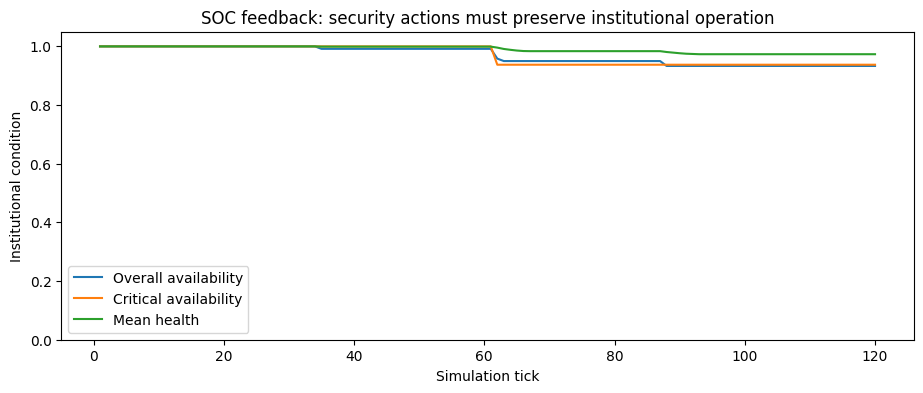

,action,status,count
1,isolate_endpoint,AUTO_APPROVED,33
2,isolate_endpoint,ESCALATE,22
3,rate_limit,AUTO_APPROVED,21
0,increase_monitoring,AUTO_APPROVED,8


### Decisions that crossed the autonomy boundary

,tick,asset_id,service,threat,confidence,action,governance_reason
2,36,E063,communications,0.462345,0.426690,isolate_endpoint,Evidence confidence is insufficient for automa...
5,37,E063,communications,0.473986,0.426690,isolate_endpoint,Evidence confidence is insufficient for automa...
7,38,E063,communications,0.473986,0.426690,isolate_endpoint,Evidence confidence is insufficient for automa...
9,39,E063,communications,0.478069,0.426690,isolate_endpoint,Evidence confidence is insufficient for automa...
11,40,E063,communications,0.482499,0.426690,isolate_endpoint,Evidence confidence is insufficient for automa...
15,62,E083,analytics,0.612675,0.465572,isolate_endpoint,Evidence confidence is insufficient for automa...
17,62,E090,analytics,0.602665,0.461757,isolate_endpoint,Evidence confidence is insufficient for automa...
28,64,E061,analytics,0.620154,0.464009,isolate_endpoint,Evidence confidence is insufficient for automa...
29,64,E090,analytics,0.618092,0.461757,isolate_endpoint,Evidence confidence is insufficient for automa...
33,65,E061,analytics,0.620154,0.464009,isolate_endpoint,Evidence confidence is insufficient for automa...


In [ ]:
# Cell 23 — visual analytics and audit trail
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(telemetry.tick, telemetry.availability, label="Overall availability")
ax.plot(telemetry.tick, telemetry.critical_availability, label="Critical availability")
ax.plot(telemetry.tick, telemetry.mean_health, label="Mean health")
ax.set_xlabel("Simulation tick")
ax.set_ylabel("Institutional condition")
ax.set_ylim(0, 1.05)
ax.set_title("SOC feedback: security actions must preserve institutional operation")
ax.legend()
plt.show()

if not audit_df.empty:
    summary = (
        audit_df.groupby(["action", "status"])
        .size().reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(summary)

    escalations = audit_df[audit_df.status == "ESCALATE"][
        ["tick", "asset_id", "service", "threat", "confidence", "action", "governance_reason"]
    ]
    display(Markdown("### Decisions that crossed the autonomy boundary"))
    display(escalations.head(20))


## Counterfactual Analysis: Aggressive Automation vs. Governed Judgment

Cell 24 introduces a structured **Counterfactual Analysis**, comparing our balanced governance model against a highly aggressive, rules-based automation policy on the exact same dataset. In the field of automated decision systems, counterfactual simulation is an essential diagnostic technique. It allows risk officers to replay historical decision logs under different policy scenarios to evaluate systemic trade-offs—such as the balance between fast mitigation and operational business disruption—without executing risky, irreversible actions in the live network.

First, the cell defines an **`aggressive_policy()`** representing a common automation pitfall. This policy operates on a simple, reactive ruleset: any asset with a threat level of `0.70` or higher is immediately isolated, while assets between `0.50` and `0.70` are rate-limited. This model represents a pure "security-first" bias, ignoring variables like the specific target function, evidence confidence, or operational impact.

Second, the code loops through the prior simulation logs, evaluating each historical scenario under both policies. It calculates the associated operational costs of each action using the **`operational_cost()`** model. The results reveal a stark contrast: the mean modeled operational cost for the aggressive policy is dramatically lower on paper (around `0.12`) because it aggressively shuts down assets. However, our governed policy displays a higher mean operational cost (around `0.202`) because it deliberately chose to preserve critical servers and escalate high-impact decisions to human operators instead of forcing automated shutdowns.

Ultimately, this analysis illustrates that blind automation of threat scores can trigger self-inflicted business crises. By separating technical recommendations from institutional permission, our governed architecture ensures that containment remains proportional to both evidence confidence and institutional authority.

In [ ]:
# Cell 24 — counterfactual: aggressive automation versus governed judgment
def aggressive_policy(threat, asset):
    if threat >= 0.70:
        return "isolate_endpoint" if asset.kind == "endpoint" else "isolate_server"
    if threat >= 0.50:
        return "rate_limit"
    return "observe"

# Compare policies on the same audited high-risk observations without executing
# dangerous or offensive behavior. This is a decision-quality counterfactual.
rows = []
if not audit_df.empty:
    for _, r in audit_df.iterrows():
        a = assets[r.asset_id]
        aggressive = aggressive_policy(r.threat, a)
        rows.append({
            "tick": r.tick,
            "asset_id": r.asset_id,
            "service": r.service,
            "threat": r.threat,
            "governed_action": r.action,
            "governed_status": r.status,
            "aggressive_action": aggressive,
            "aggressive_operational_cost": operational_cost(a, aggressive, G),
            "governed_operational_cost": operational_cost(a, r.action, G)
        })

counterfactual = pd.DataFrame(rows)
if not counterfactual.empty:
    display(counterfactual.head(20))
    print(
        "Mean modeled operational cost — aggressive:",
        round(counterfactual.aggressive_operational_cost.mean(), 3)
    )
    print(
        "Mean modeled operational cost — governed:",
        round(counterfactual.governed_operational_cost.mean(), 3)
    )

display(Markdown(r"""
### Interpretation
The aggressive policy embodies a common automation mistake: **high estimated threat automatically implies aggressive containment**. The governed system treats that conclusion as incomplete. It asks what the asset does, what depends on it, how certain the evidence is, whether the action is reversible, and whether the machine has authority to impose the consequence.

The lesson is not that intervention is undesirable. It is that **autonomous action should be proportional to both evidence and institutional authority**.
"""))


,tick,asset_id,service,threat,governed_action,governed_status,aggressive_action,aggressive_operational_cost,governed_operational_cost
0,35,E063,communications,0.508698,isolate_endpoint,AUTO_APPROVED,rate_limit,0.094581,0.208079
1,35,S010,communications,0.426449,increase_monitoring,AUTO_APPROVED,observe,0.000000,0.058772
2,36,E063,communications,0.462345,isolate_endpoint,ESCALATE,observe,0.000000,0.208079
3,36,S010,communications,0.425729,increase_monitoring,AUTO_APPROVED,observe,0.000000,0.058772
4,37,S010,communications,0.478245,increase_monitoring,AUTO_APPROVED,observe,0.000000,0.058772
5,37,E063,communications,0.473986,isolate_endpoint,ESCALATE,observe,0.000000,0.208079
6,38,S010,communications,0.475421,increase_monitoring,AUTO_APPROVED,observe,0.000000,0.058772
7,38,E063,communications,0.473986,isolate_endpoint,ESCALATE,observe,0.000000,0.208079
8,39,S010,communications,0.478263,increase_monitoring,AUTO_APPROVED,observe,0.000000,0.058772
9,39,E063,communications,0.478069,isolate_endpoint,ESCALATE,observe,0.000000,0.208079


Mean modeled operational cost — aggressive: 0.12
Mean modeled operational cost — governed: 0.202



### Interpretation
The aggressive policy embodies a common automation mistake: **high estimated threat automatically implies aggressive containment**. The governed system treats that conclusion as incomplete. It asks what the asset does, what depends on it, how certain the evidence is, whether the action is reversible, and whether the machine has authority to impose the consequence.

The lesson is not that intervention is undesirable. It is that **autonomous action should be proportional to both evidence and institutional authority**.


## The Interactive SOC Command Center and Concluding Framework

Cell 25 implements an interactive **SOC Command Center Dashboard** using the Gradio library and provides the overall architectural conclusions of our simulated security system. Up to this point, our experiments have run on pre-scheduled simulation timelines. This interactive dashboard bridges the gap between batch-processed code and live operational utility, giving human operators a simple, visual control console to pressure-test the underlying decision and governance models under custom, real-time threat conditions.

First, the dashboard allows users to dynamically configure a security scenario by selecting any asset from our generated network registry. Using intuitive slider controls, operators can manipulate synthetic evidence metrics, including the perceived threat estimate, the confidence level of that evidence, and the propagation pressure facing the target. When the user clicks "Evaluate defensive decision," the interface executes our real backend code, instantly showing the ranked action alternatives, their calculated security-benefit and operational-cost trade-offs, and the final decision of the **`governance_gate()`**.

Second, this interactive tool illustrates the notebook’s ultimate takeaway: **a high threat score is not an instruction, but merely a data point within a broader decision framework**. By altering parameters for high-criticality assets, users can witness the system transition from autonomous containment to human escalation, highlighting the boundary of delegated machine authority.

Ultimately, this brings us to the core four-part loop of our autonomous architecture: **Perception** (interpreting what is happening), **Judgment** (determining what should be done), **Governance** (verifying if the machine has the authority to act), and **Feedback** (adapting after action is taken). The system concludes not as a completely unmonitored cyber actor, but as a model of defensive institutional intelligence designed to operate continuously while respecting its own limits.

In [ ]:
# Cell 25 — interactive SOC command-center app
display(Markdown(r"""
# Command Center

The app below is a thin interface over the same simulation and judgment functions used above. It does not implement a second hidden model. Choose an asset, vary the synthetic evidence, and inspect the proposed defensive action and governance status.

In Colab, run this cell and use the Gradio link. If Gradio is unavailable, the notebook itself remains fully functional.
"""))

def evaluate_case(asset_id, threat, confidence, propagation):
    a = assets[asset_id]
    ranked = judge_actions(a, float(threat), float(confidence), float(propagation), G)
    proposal = ranked.iloc[0].to_dict()
    gate = governance_gate(a, proposal, float(threat), float(confidence))

    explanation = (
        f"Asset {a.asset_id} | {a.kind} | service={a.service} | "
        f"criticality={a.criticality:.2f}\n\n"
        f"Recommended action: {proposal['action']}\n"
        f"Judgment score: {proposal['score']:.3f}\n"
        f"Security benefit: {proposal['security_benefit']:.3f}\n"
        f"Operational cost: {proposal['operational_cost']:.3f}\n"
        f"Reversibility: {proposal['reversibility']:.2f}\n"
        f"Governance: {gate['status']}\n"
        f"Reason: {gate['reason']}"
    )
    return explanation, ranked

try:
    import gradio as gr

    with gr.Blocks(title="Autonomous SOC — Judgment Simulator") as demo:
        gr.Markdown(
            "# Autonomous SOC — Judgment Simulator\n"
            "Synthetic defensive decision support: **detect → judge → govern → act → learn**."
        )
        with gr.Row():
            asset_box = gr.Dropdown(
                choices=sorted(assets.keys()),
                value=sorted(assets.keys())[0],
                label="Synthetic asset"
            )
            threat_box = gr.Slider(0, 1, value=0.70, step=0.01, label="Threat estimate")
            confidence_box = gr.Slider(0, 1, value=0.65, step=0.01, label="Evidence confidence")
            propagation_box = gr.Slider(0, 1, value=0.40, step=0.01, label="Propagation pressure")

        run_btn = gr.Button("Evaluate defensive decision")
        explanation_box = gr.Textbox(label="Judgment and governance", lines=10)
        table_box = gr.Dataframe(label="Ranked defensive alternatives", interactive=False)

        run_btn.click(
            fn=evaluate_case,
            inputs=[asset_box, threat_box, confidence_box, propagation_box],
            outputs=[explanation_box, table_box]
        )

    print("App constructed. In Colab, run: demo.launch(share=True)")
except Exception as e:
    print(f"Gradio app could not be constructed: {type(e).__name__}: {e}")
    print("The simulation and judgment engine above remain fully usable.")

display(Markdown(r"""
## Conclusion

This experiment shows why a self-driving institution cannot be reduced to prediction or optimization. The SOC observes a changing environment, constructs an interpretation, evaluates alternatives, acts within bounded authority, observes the consequences, and revises its view. Yet the most important design feature is the **gap between recommendation and permission**.

A high threat score is not an instruction. It is evidence entering a decision.

That distinction becomes decisive when the affected asset is systemically important. Isolating an ordinary endpoint and isolating an identity or payment server may look similar in a cybersecurity taxonomy, but they are profoundly different institutional decisions. The second can create a new operational crisis while attempting to solve the first.

The architecture therefore separates four questions:

**What is happening?** — perception and assessment.

**What should we do?** — judgment under uncertainty and competing objectives.

**May the machine do it?** — governance and delegated authority.

**What happened after we acted?** — feedback and adaptation.

This is the broader lesson for autonomous systems. Intelligence is not merely the ability to choose an action with a high numerical score. Mature autonomy requires knowing when consequences, uncertainty, irreversibility, and institutional mandate make escalation preferable to automatic execution.

The notebook intentionally ends with a bounded command center rather than an autonomous cyber actor. Its purpose is to demonstrate **defensive institutional intelligence**: a system capable of operating continuously while remaining explicit about the limits of its own authority.
"""))



# Command Center

The app below is a thin interface over the same simulation and judgment functions used above. It does not implement a second hidden model. Choose an asset, vary the synthetic evidence, and inspect the proposed defensive action and governance status.

In Colab, run this cell and use the Gradio link. If Gradio is unavailable, the notebook itself remains fully functional.


App constructed. In Colab, run: demo.launch(share=True)



## Conclusion

This experiment shows why a self-driving institution cannot be reduced to prediction or optimization. The SOC observes a changing environment, constructs an interpretation, evaluates alternatives, acts within bounded authority, observes the consequences, and revises its view. Yet the most important design feature is the **gap between recommendation and permission**.

A high threat score is not an instruction. It is evidence entering a decision.

That distinction becomes decisive when the affected asset is systemically important. Isolating an ordinary endpoint and isolating an identity or payment server may look similar in a cybersecurity taxonomy, but they are profoundly different institutional decisions. The second can create a new operational crisis while attempting to solve the first.

The architecture therefore separates four questions:

**What is happening?** — perception and assessment.

**What should we do?** — judgment under uncertainty and competing objectives.

**May the machine do it?** — governance and delegated authority.

**What happened after we acted?** — feedback and adaptation.

This is the broader lesson for autonomous systems. Intelligence is not merely the ability to choose an action with a high numerical score. Mature autonomy requires knowing when consequences, uncertainty, irreversibility, and institutional mandate make escalation preferable to automatic execution.

The notebook intentionally ends with a bounded command center rather than an autonomous cyber actor. Its purpose is to demonstrate **defensive institutional intelligence**: a system capable of operating continuously while remaining explicit about the limits of its own authority.


In [ ]:
 demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a2cbd84cc25a93a0d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
